# Задача: Отобразить высокомерные данные $X ∈ ℝ^D$ в низкомерное пространство $Y ∈ ℝ^d (d=2,3)$ так, чтобы сохранить структуру соседства.

    1. Вероятностная постановка задачи


Задача: Отобразить высокомерные данные $X ∈ ℝ^D$ в низкомерное пространство $Y ∈ ℝ^d (d=2,3)$
так, чтобы сохранить структуру соседства.


        - Вероятности в исходном пространстве

Гауссово ядро для измерения сходства:

$
p_{j|i} = exp(-||x_i - x_j||^2 / (2σ_i^2)) / Σ_{k≠i} exp(-||x_i - x_k||^2 / (2σ_i^2))$

Симметризация вероятностей:

$
p_{ij} = (p_{j|i} + p_{i|j}) / (2n)$

Перплексия (perplexity) как гиперпараметр:

$
Perp(P_i) = 2^{H(P_i)}, $

где $H(P_i) = -Σ_j p_{j|i} log₂ p_{j|i}$

        - Вероятности в целевом пространстве

Распределение Стьюдента с одной степенью свободы:

$
q_{ij} = (1 + ||y_i - y_j||^2)^{-1} / Σ_{k≠l} (1 + ||y_k - y_l||^2)^{-1}$

Преимущества t-распределения:

       * Тяжелые хвосты

       * Устойчивость к проклятию размерности

       * Улучшенное разделение кластеров

       * Функция стоимости (KL-дивергенция)

$C(Y) = KL(P||Q) = Σ_i Σ_j p_{ij} log(p_{ij} / q_{ij})$

    2. Оптимизация функции стоимости

        2.1. Градиент функции стоимости

$∂C/∂y_i = 4 Σ_j (p_{ij} - q_{ij})(y_i - y_j)(1 + ||y_i - y_j||^2)^{-1}$

       2.2. Методы оптимизации

Градиентный спуск с моментумом:

$Y^{(t)} = Y^{(t-1)} + η ∂C/∂Y + α(t)(Y^{(t-1)} - Y^{(t-2)})$


Раннее преувеличение (early exaggeration):


$p_{ij} ← p_{ij} × 4 (первые 100 итераций)$


Адаптивное обучение (adaptive learning rate)

        2.3. Сложности оптимизации

            - Невыпуклость функции стоимости

            - Локальные минимумы

            - Чувствительность к начальной инициализации

            - Вычислительная сложность O(n²)

Импорт библиотек

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Задание

1. Провести исследование влияния гиперпараметров на результаты кластеризации с T-SNE
2. Сравнить с PCA
   
Использовать 2 датасета - стандартного типа Ирис или Цифры, и своего. Не забываем про нормировку и eda в целом

In [27]:
path = "online_shoppers_intention.csv" 

df = pd.read_csv(path)
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [28]:
from sklearn.datasets import load_digits

# 1. Загрузка данных
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

Разделить выборку на фичи и целевую переменную

In [29]:
# предварительная обработка категориальных признаков
df_prep = df.copy()

df_prep["Weekend"] = df_prep["Weekend"].map({False:0, True:1})
df_prep["Revenue"] = df_prep["Revenue"].map({False:0, True:1})

df_prep["VisitorType"] = df_prep["VisitorType"].map({
    "Returning_Visitor":1,
    "New_Visitor":0,
    "Other":2
})

df_prep = pd.get_dummies(df_prep, columns=["Month"], drop_first=True)

feature_cols = df_prep.columns.drop("Revenue")

X_csv = df_prep[feature_cols]
y_csv = df_prep["Revenue"]

print(X_csv.shape, y_csv.shape)
print(X_digits.shape, y_digits.shape)

(12330, 25) (12330,)
(1797, 64) (1797,)


Нормировка

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_digits_scaled = scaler.fit_transform(X_digits)
X_csv_scaled = scaler.fit_transform(X_csv)

pca = PCA(n_components=2, random_state=42)

Digits — доля объяснённой дисперсии: [0.12033916 0.09561054] Суммарно: 0.21594970500832794
Shoppers — доля объяснённой дисперсии: [0.1393329  0.07539576] Суммарно: 0.21472865898070814


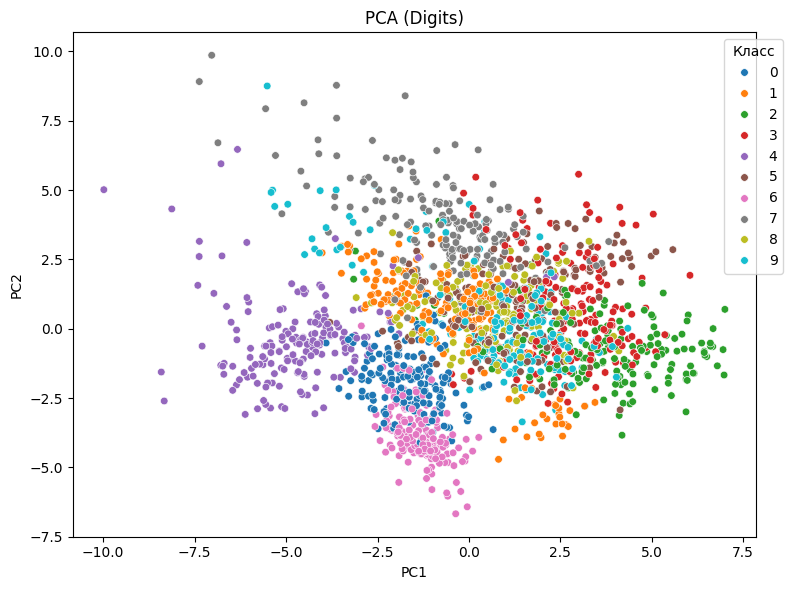

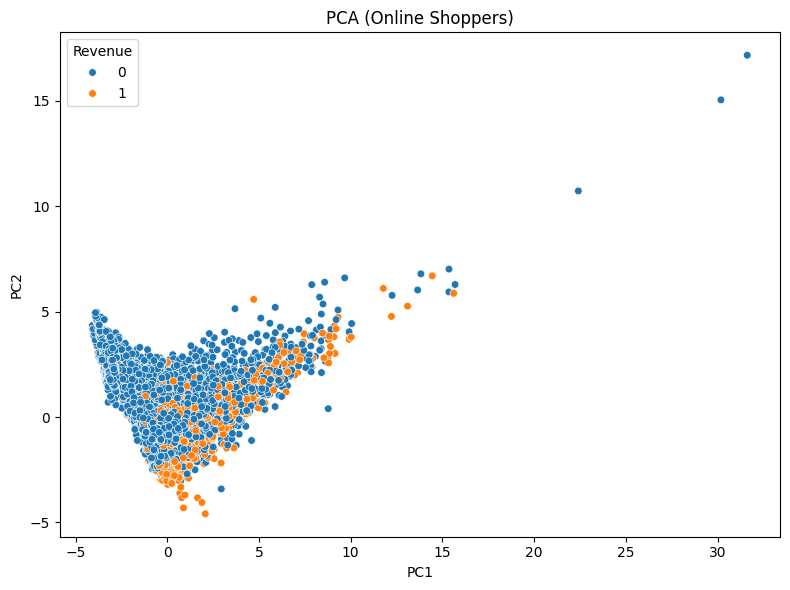

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca_digits = pca.fit_transform(X_digits_scaled)
print("Digits — доля объяснённой дисперсии:", pca.explained_variance_ratio_,
      "Суммарно:", pca.explained_variance_ratio_.sum())

X_pca_csv = pca.fit_transform(X_csv_scaled)
print("Shoppers — доля объяснённой дисперсии:", pca.explained_variance_ratio_,
      "Суммарно:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8,6))

sns.scatterplot(x=X_pca_digits[:,0],
                y=X_pca_digits[:,1],
                hue=y_digits,
                palette="tab10",
                s=30)

plt.title("PCA (Digits)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend(title="Класс", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(x=X_pca_csv[:,0],
                y=X_pca_csv[:,1],
                hue=y_csv,
                s=30)

plt.title("PCA (Online Shoppers)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

TSNE 2 компоненты

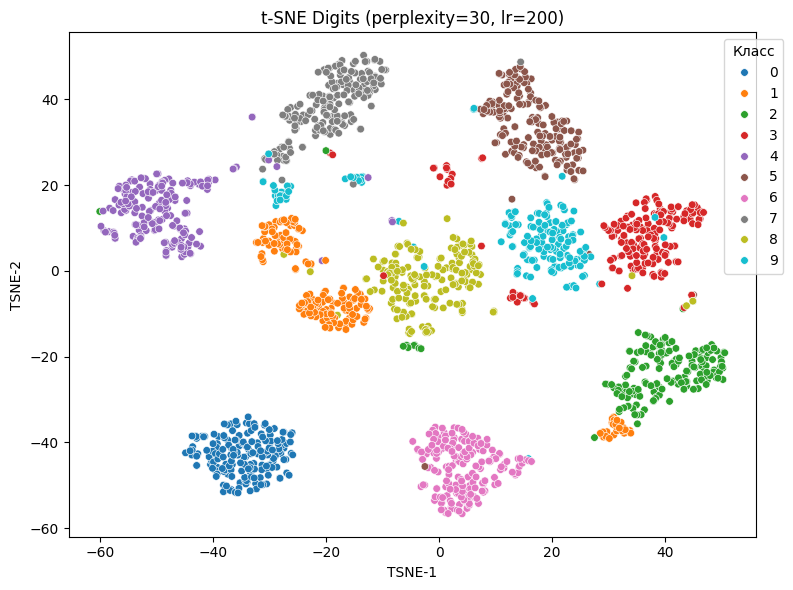

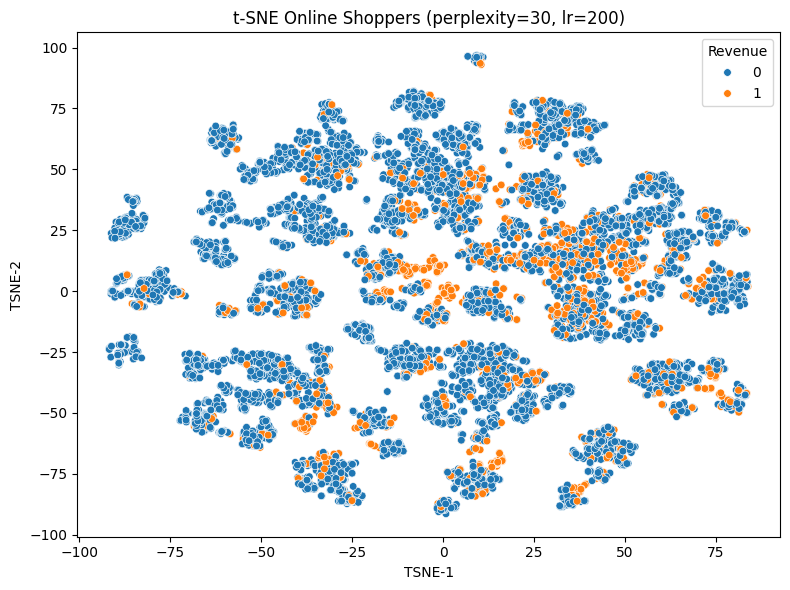

In [32]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne_digits = tsne.fit_transform(X_digits_scaled)
X_tsne_csv = tsne.fit_transform(X_csv_scaled)
plt.figure(figsize=(8,6))

sns.scatterplot(x=X_tsne_digits[:,0],
                y=X_tsne_digits[:,1],
                hue=y_digits,
                palette="tab10",
                s=30)

plt.title("t-SNE Digits (perplexity=30, lr=200)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")

plt.legend(title="Класс", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()
plt.figure(figsize=(8,6))

sns.scatterplot(x=X_tsne_csv[:,0],
                y=X_tsne_csv[:,1],
                hue=y_csv,
                s=30)

plt.title("t-SNE Online Shoppers (perplexity=30, lr=200)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import pairwise_distances

def separation_score(X_2d, y):

    D = pairwise_distances(X_2d)

    same = D[y[:,None] == y[None,:]]
    diff = D[y[:,None] != y[None,:]]

    return same.mean(), diff.mean(), diff.mean()/same.mean()
pca_same, pca_diff, pca_ratio = separation_score(X_pca_digits, y_digits)

tsne_same, tsne_diff, tsne_ratio = separation_score(X_tsne_digits, y_digits)

print("Digits PCA: внутри =", pca_same,
      "между =", pca_diff,
      "ratio =", pca_ratio)

print("Digits t-SNE: внутри =", tsne_same,
      "между =", tsne_diff,
      "ratio =", tsne_ratio)
pca_same, pca_diff, pca_ratio = separation_score(X_pca_csv, y_csv.values)

tsne_same, tsne_diff, tsne_ratio = separation_score(X_tsne_csv, y_csv.values)

print("Shoppers PCA: внутри =", pca_same,
      "между =", pca_diff,
      "ratio =", pca_ratio)

print("Shoppers t-SNE: внутри =", tsne_same,
      "между =", tsne_diff,
      "ratio =", tsne_ratio)

Digits PCA: внутри = 2.468234399163823 между = 4.761456156687809 ratio = 1.9290939945982737
Digits t-SNE: внутри = 13.999029 между = 55.664757 ratio = 3.9763298
Shoppers PCA: внутри = 2.532104760339837 между = 2.7782242072739103 ratio = 1.0971995514518291
Shoppers t-SNE: внутри = 79.62575 между = 76.179245 ratio = 0.95671624


Вычислить и отрисовать T-SNE с разным значением Perplexity

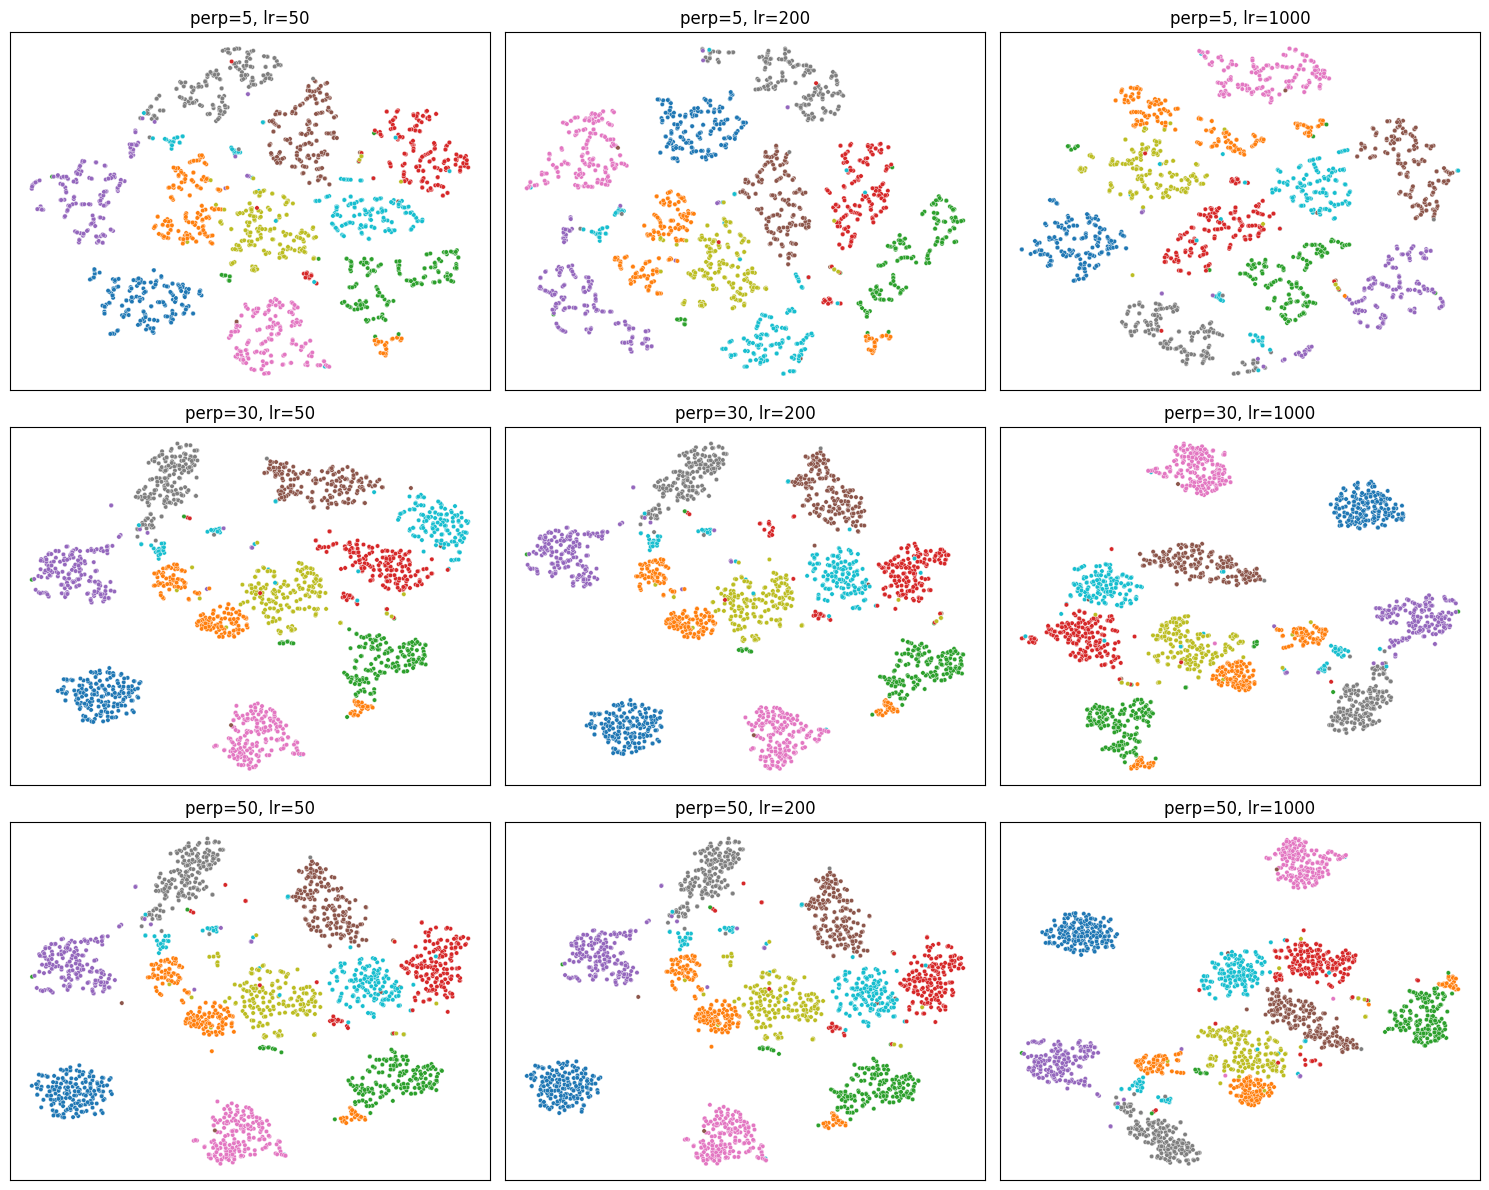

In [34]:
perplexities = [5, 30, 50]
learning_rates = [50, 200, 1000]

fig, axes = plt.subplots(len(perplexities), len(learning_rates),
                         figsize=(5*len(learning_rates),4*len(perplexities)))

for i, perp in enumerate(perplexities):

    for j, lr in enumerate(learning_rates):

        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            learning_rate=lr,
            random_state=42
        )

        X_emb = tsne.fit_transform(X_digits_scaled)

        ax = axes[i,j]

        sns.scatterplot(x=X_emb[:,0],
                        y=X_emb[:,1],
                        hue=y_digits,
                        palette="tab10",
                        s=10,
                        ax=ax,
                        legend=False)

        ax.set_title(f"perp={perp}, lr={lr}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

Проанализируйте:

как меняется форма кластеров,

возникают ли “разрывы” или слияния при разных параметрах,

насколько стабилен рисунок при небольших изменениях параметров.

ВЫВОДЫ

При малой perplexity (5) кластеры становятся более фрагментированными, возможны разрывы одного класса на несколько групп.

При perplexity = 30 наблюдается наиболее чёткое разделение кластеров и компактная структура.

При большом learning rate структура может становиться менее стабильной, некоторые кластеры смещаются или сближаются.
t-SNE значительно лучше разделяет кластеры, хотя PCA более устойчивый к изменению параметров.

PCA: устойчивая структура
Для PCA параметров немного (по сути только число компонент), проекция при фиксированном random_state практически не меняется, что показывает устойчивость метода.


In [35]:
pca_10 = PCA(n_components=10, random_state=42)
X_pca_10 = pca_10.fit_transform(X_scaled)

print("Суммарная объяснённая дисперсия (10 компонент):",
      pca_10.explained_variance_ratio_.sum())


Суммарная объяснённая дисперсия (10 компонент): 0.58873755337303
